In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import sys
sys.path.append("../utils")
from analyze_stock import analyze_stock

print("All imports successful")

All imports successful


In [4]:
code = '''import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

def analyze_stock(ticker, start="2022-01-01", end="2024-12-31"):
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price   = df["Close"]
    returns = np.log(price / price.shift(1)).dropna()

    ann_return = returns.mean() * 252
    ann_vol    = returns.std()  * np.sqrt(252)
    sharpe     = ann_return / ann_vol

    stats = {
        "ticker"       : ticker,
        "ann_return"   : ann_return,
        "ann_vol"      : ann_vol,
        "sharpe"       : sharpe,
        "worst_day"    : returns.min(),
        "best_day"     : returns.max(),
        "total_return" : (price.iloc[-1] / price.iloc[0]) - 1,
    }

    print(f"\\n{\'=\'*40}")
    print(f"  {ticker} | {start} to {end}")
    print(f"{\'=\'*40}")
    for k, v in stats.items():
        if k == "ticker":
            pass
        elif k == "sharpe":
            print(f"  {k:<20} {v:>8.2f}")
        elif isinstance(v, float):
            print(f"  {k:<20} {v:>8.2%}")

    sma50 = price.rolling(window=50).mean()
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5),
        gridspec_kw={"height_ratios": [3, 1]}, sharex=True)
    ax1.plot(price, lw=1.2, color="#2563eb", label="Price")
    ax1.plot(sma50, lw=1.5, color="#f97316",
             linestyle="--", label="50-day SMA")
    ax1.legend()
    ax1.set_title(f"{ticker} -- Ann. Return {ann_return:.1%} | Sharpe {sharpe:.2f}")
    ax1.grid(True, alpha=0.3)
    ax2.bar(df.index, df["Volume"], color="#94a3b8", alpha=0.7)
    ax2.set_ylabel("Volume")
    plt.tight_layout()
    plt.show()

    return stats
'''

with open("../utils/analyze_stock.py", "w", encoding="utf-8") as f:
    f.write(code)

print("Fixed and saved")

Fixed and saved


In [7]:
df = yf.download("SPY", start="2019-01-01",
                 end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"]
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(log_returns)} observations")
print(f"Date range: {price.index[0].date()} to {price.index[-1].date()}")

[*********************100%***********************]  1 of 1 completed

Loaded 1257 observations
Date range: 2019-01-02 to 2023-12-29


In [8]:
# Risk free rate (approximate US 3-month T-bill average)
rf_daily = 0.02 / 252

# Sharpe ratio
excess_returns = log_returns - rf_daily
sharpe = excess_returns.mean() / excess_returns.std() * np.sqrt(252)

# Sortino ratio — only penalises downside volatility
downside_returns = log_returns[log_returns < rf_daily]
downside_std     = downside_returns.std() * np.sqrt(252)
sortino = (log_returns.mean() * 252 - 0.02) / downside_std

print("=" * 40)
print("  SHARPE & SORTINO")
print("=" * 40)
print(f"  Sharpe Ratio  : {sharpe:>8.2f}")
print(f"  Sortino Ratio : {sortino:>8.2f}")
print(f"  Downside Vol  : {downside_std:>8.2%}")
print(f"  Total Vol     : {log_returns.std()*np.sqrt(252):>8.2%}")
print("=" * 40)
print(f"\n  Sortino > Sharpe means losses are")
print(f"  less extreme than gains — good sign")

  SHARPE & SORTINO
  Sharpe Ratio  :     0.59
  Sortino Ratio :     0.70
  Downside Vol  :   17.78%
  Total Vol     :   21.08%

  Sortino > Sharpe means losses are
  less extreme than gains — good sign


MAXIMUM DRAWDOWN
 Max Drawdown :  -35.75%
 Occurred on : 2020-03-23


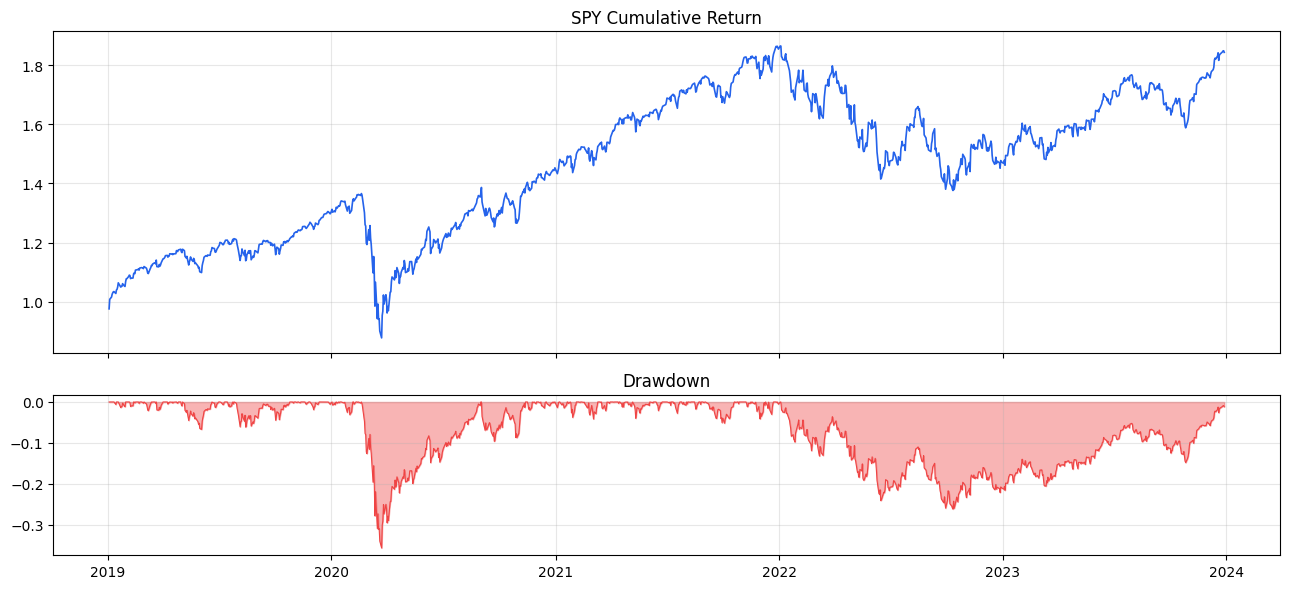

In [10]:
#Maximum drawdown
def max_drawdown(returns):
    #Build cumulative wealth index
    wealth = (1 + returns).cumprod()

    #Rolling peak
    rolling_peak = wealth.cummax()

    #Drawdown at each point
    drawdown = (wealth - rolling_peak) / rolling_peak

    max_dd = drawdown.min()
    max_dd_date =drawdown.idxmin()

    return max_dd, max_dd_date, drawdown

max_dd, max_dd_date, drawdown = max_drawdown(log_returns)

print("=" * 40)
print("MAXIMUM DRAWDOWN")
print("=" * 40)
print(f" Max Drawdown : {max_dd:>8.2%}")
print(f" Occurred on : {max_dd_date.date()}")
print("=" * 40)

#Plot drawdown over time
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6),
                               gridspec_kw={'height_ratios': [2, 1]}, sharex=True)
wealth = (1 + log_returns).cumprod()
ax1.plot(wealth, color='#2563eb', lw=1.2)
ax1.set_title('SPY Cumulative Return')
ax1.grid(True, alpha=0.3)

ax2.fill_between(drawdown.index, drawdown, 0,
                 color='#ef4444', alpha=0.4)
ax2.plot(drawdown, color='#ef4444', lw=0.8)
ax2.set_title('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
#Value at Risk (VaR) and Conditional VaR (CVaR)
def var_cvar(returns, confidence=0.95):
    """
    Historical VaR and CVaR at given confidence level.
    VaR-worst loss on (1-confidence)% of days
    CVaR-average loss on those worst days
    """
    sorted_returns = returns.sort_values()
    cutoff_idx = int((1 - confidence) * len(sorted_returns))

    var = sorted_returns.iloc[cutoff_idx]
    cvar = sorted_returns.iloc[:cutoff_idx].mean()

    return var, cvar

var_95, cvar_95 = var_cvar(log_returns, 0.95)
var_99, cvar_99 = var_cvar(log_returns, 0.99)

print("=" * 45)
print(" VALUE AT RISK (Historical Method)")
print("=" * 45)
print(f" 95% VaR : {var_95:>8.2%} (1 in 20 days)")
print(f" 95% CVaR : {cvar_95:>8.2%} (avg af worst 5%)")
print(f" 99% VaR : {var_99:>8.2%} (1 in 100 days)")
print(f" 99% CVaR : {cvar_99:>8.2%} (avg of worst 1 %)")
print("=" * 45)
print(f"\n On a $10,000 position:")
print(f" Expect to lose more than ${abs(var_95)*10000:,.0f} once every 20 days")
print(f" when it's really bad, expect to lose ${abs(cvar_99)*10000:,.0f}")

 VALUE AT RISK (Historical Method)
 95% VaR :   -1.96% (1 in 20 days)
 95% CVaR :   -3.30% (avg af worst 5%)
 99% VaR :   -3.77% (1 in 100 days)
 99% CVaR :   -6.00% (avg of worst 1 %)

 On a $10,000 position:
 Expect to lose more than $196 once every 20 days
 when it's really bad, expect to lose $600


[*********************100%***********************]  1 of 1 completed



  SPY RISK REPORT
  Ann. Return    :   14.50%
  Ann. Volatility:   21.08%
  Sharpe Ratio   :     0.59
  Sortino Ratio  :     0.70
  Max Drawdown   :  -35.75%  (2020-03-23)
  95% VaR        :   -1.96%
  95% CVaR       :   -3.30%
  99% VaR        :   -3.77%
  99% CVaR       :   -6.00%


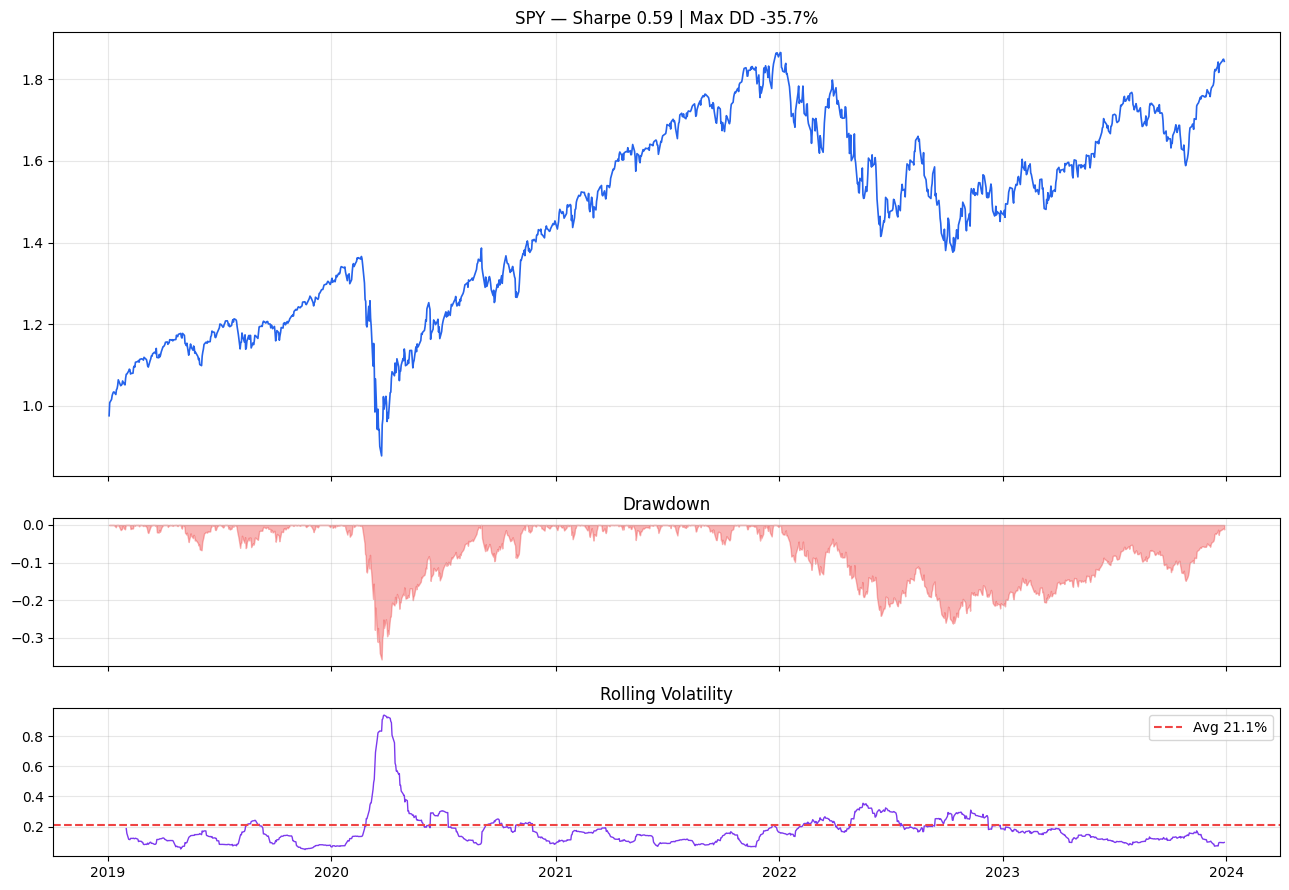

[*********************100%***********************]  1 of 1 completed



  AAPL RISK REPORT
  Ann. Return    :   32.59%
  Ann. Volatility:   32.25%
  Sharpe Ratio   :     0.95
  Sortino Ratio  :     1.27
  Max Drawdown   :  -35.18%  (2023-01-05)
  95% VaR        :   -3.12%
  95% CVaR       :   -4.75%
  99% VaR        :   -5.73%
  99% CVaR       :   -7.93%


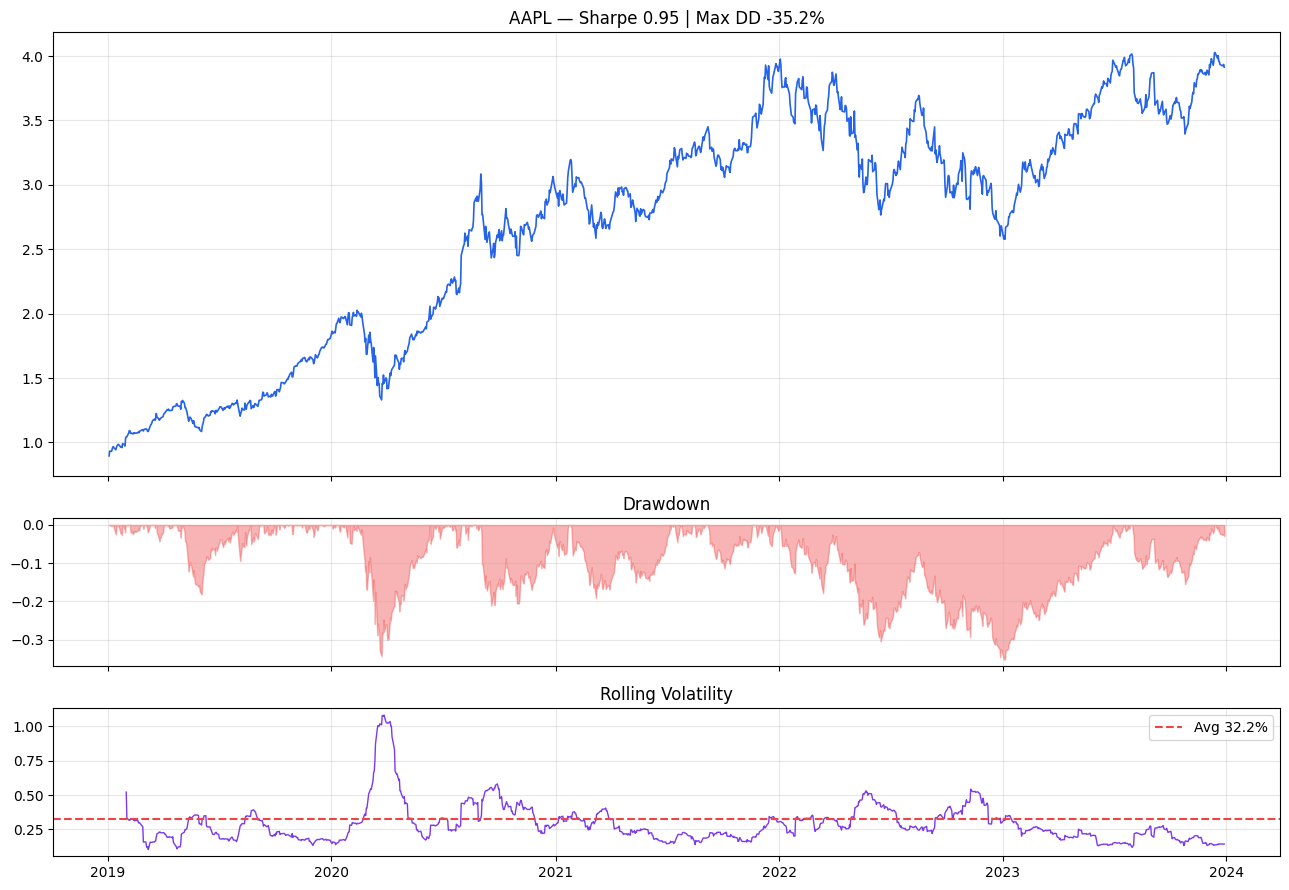

[*********************100%***********************]  1 of 1 completed



  BTC-USD RISK REPORT
  Ann. Return    :   33.11%
  Ann. Volatility:   56.25%
  Sharpe Ratio   :     0.55
  Sortino Ratio  :     0.68
  Max Drawdown   :  -83.72%  (2022-11-21)
  95% VaR        :   -5.15%
  95% CVaR       :   -8.41%
  99% VaR        :  -10.21%
  99% CVaR       :  -14.62%


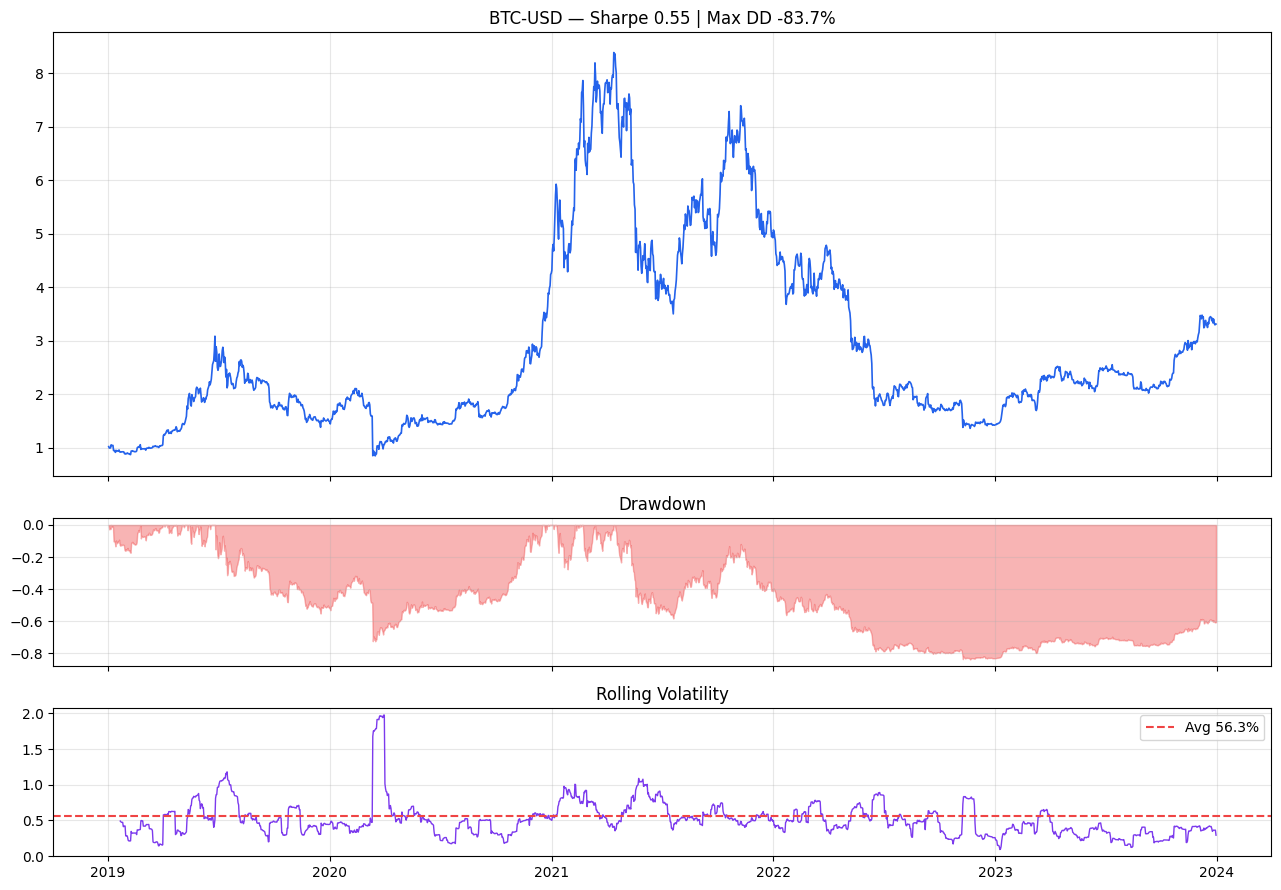

{'sharpe': np.float64(0.5529644232817512),
 'sortino': np.float64(0.6813909390821132),
 'max_dd': np.float64(-0.8371556389777988),
 'var_95': np.float64(-0.051488267863326775),
 'cvar_99': np.float64(-0.14622333545549793)}

In [14]:
def risk_report(ticker, start="2019-01-01", end="2024-01-01"):
    """
    Complete risk report for any ticker.
    Sharpe, Sortino, Max Drawdown, VaR, CVaR.
    """
    # --- Data ---
    df = yf.download(ticker, start=start, end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price   = df["Close"]
    returns = np.log(price / price.shift(1)).dropna()

    # --- Metrics ---
    rf_daily      = 0.02 / 252
    excess        = returns - rf_daily
    sharpe        = excess.mean() / excess.std() * np.sqrt(252)
    down_std      = returns[returns < rf_daily].std() * np.sqrt(252)
    sortino       = (returns.mean() * 252 - 0.02) / down_std
    wealth        = (1 + returns).cumprod()
    drawdown      = (wealth - wealth.cummax()) / wealth.cummax()
    max_dd        = drawdown.min()
    max_dd_date   = drawdown.idxmin()
    var_95        = returns.sort_values().iloc[int(0.05 * len(returns))]
    cvar_95       = returns.sort_values().iloc[:int(0.05 * len(returns))].mean()
    var_99        = returns.sort_values().iloc[int(0.01 * len(returns))]
    cvar_99       = returns.sort_values().iloc[:int(0.01 * len(returns))].mean()
    ann_return    = returns.mean() * 252
    ann_vol       = returns.std()  * np.sqrt(252)

    # --- Print ---
    print(f"\n{'='*45}")
    print(f"  {ticker} RISK REPORT")
    print(f"{'='*45}")
    print(f"  Ann. Return    : {ann_return:>8.2%}")
    print(f"  Ann. Volatility: {ann_vol:>8.2%}")
    print(f"  Sharpe Ratio   : {sharpe:>8.2f}")
    print(f"  Sortino Ratio  : {sortino:>8.2f}")
    print(f"  Max Drawdown   : {max_dd:>8.2%}  ({max_dd_date.date()})")
    print(f"  95% VaR        : {var_95:>8.2%}")
    print(f"  95% CVaR       : {cvar_95:>8.2%}")
    print(f"  99% VaR        : {var_99:>8.2%}")
    print(f"  99% CVaR       : {cvar_99:>8.2%}")
    print(f"{'='*45}")

    # --- 3 panel chart ---
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9),
        gridspec_kw={'height_ratios': [3, 1, 1]}, sharex=True)

    ax1.plot(wealth, color='#2563eb', lw=1.2)
    ax1.set_title(f'{ticker} — Sharpe {sharpe:.2f} | Max DD {max_dd:.1%}')
    ax1.grid(True, alpha=0.3)

    ax2.fill_between(drawdown.index, drawdown, 0,
                     color='#ef4444', alpha=0.4)
    ax2.set_title('Drawdown')
    ax2.grid(True, alpha=0.3)

    roll_vol = returns.rolling(20).std() * np.sqrt(252)
    ax3.plot(roll_vol, color='#7c3aed', lw=1)
    ax3.axhline(ann_vol, color='#ef4444', lw=1.5,
                linestyle='--', label=f'Avg {ann_vol:.1%}')
    ax3.set_title('Rolling Volatility')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return {"sharpe": sharpe, "sortino": sortino,
            "max_dd": max_dd, "var_95": var_95, "cvar_99": cvar_99}

# Test on all 3 assets
risk_report("SPY")
risk_report("AAPL")
risk_report("BTC-USD")